In [1]:
import io
import os
import re
import shutil
import tarfile
import string
import torch
import tiktoken
import requests
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from sklearn.metrics import classification_report
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import matplotlib as plt

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [2]:
# %pip install torch
# %pip install tiktoken

In [2]:
data = pd.read_csv('../data/spam.csv', encoding='ISO-8859-1')
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
data.shape

(5572, 5)

In [5]:
data.isna().sum() / data.shape[0]

v1            0.000000
v2            0.000000
Unnamed: 2    0.991027
Unnamed: 3    0.997846
Unnamed: 4    0.998923
dtype: float64

In [6]:
data['v1'].value_counts()

v1
ham     4825
spam     747
Name: count, dtype: int64

In [7]:
px.histogram(data, data['v1'])

In [8]:
data.dropna(axis=1, inplace=True)
data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
data.columns = ['label', 'messages']
data.head()

,label,messages
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
data['label'] = data['label'].map({'ham':0, 'spam':1})
data.head()

,label,messages
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
tokenizer = tiktoken.get_encoding("cl100k_base")

def encode_texts(texts):
    return [tokenizer.encode(text) for text in texts]

data['messages_tokenized'] = encode_texts(data['messages'])

train_tokens = data['messages_tokenized']

data.head()

,label,messages,messages_tokenized
0,0,"Go until jurong point, crazy.. Available only ...","[11087, 3156, 16422, 647, 1486, 11, 14599, 497..."
1,0,Ok lar... Joking wif u oni...,"[11839, 45555, 1131, 622, 10979, 289, 333, 577..."
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,"[11180, 4441, 304, 220, 17, 264, 74860, 398, 1..."
3,0,U dun say so early hor... U c already then say...,"[52, 50116, 2019, 779, 4216, 4917, 1131, 549, ..."
4,0,"Nah I don't think he goes to usf, he lives aro...","[45, 1494, 358, 1541, 956, 1781, 568, 5900, 31..."


In [12]:
# How are sequence lengths distributed?
seq_lens = [len(seq) for seq in data['messages_tokenized']]
print('Avg seq len',  np.mean(seq_lens))
print('Max seq len', np.max(seq_lens))
print('Std seq len', np.std(seq_lens))

Avg seq len 22.49551328068916
Max seq len 259
Std seq len 17.319890966326266


In [13]:
vocab_size = tokenizer.n_vocab
pad_id = vocab_size

def pad_sequences(sequences, max_length=40):
    return [seq[:max_length] + [pad_id] * (max_length - len(seq)) for seq in sequences]

data['token_pad'] = pad_sequences(train_tokens)

data.head()

,label,messages,messages_tokenized,token_pad
0,0,"Go until jurong point, crazy.. Available only ...","[11087, 3156, 16422, 647, 1486, 11, 14599, 497...","[11087, 3156, 16422, 647, 1486, 11, 14599, 497..."
1,0,Ok lar... Joking wif u oni...,"[11839, 45555, 1131, 622, 10979, 289, 333, 577...","[11839, 45555, 1131, 622, 10979, 289, 333, 577..."
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,"[11180, 4441, 304, 220, 17, 264, 74860, 398, 1...","[11180, 4441, 304, 220, 17, 264, 74860, 398, 1..."
3,0,U dun say so early hor... U c already then say...,"[52, 50116, 2019, 779, 4216, 4917, 1131, 549, ...","[52, 50116, 2019, 779, 4216, 4917, 1131, 549, ..."
4,0,"Nah I don't think he goes to usf, he lives aro...","[45, 1494, 358, 1541, 956, 1781, 568, 5900, 31...","[45, 1494, 358, 1541, 956, 1781, 568, 5900, 31..."


In [14]:
from sklearn.model_selection import train_test_split
x = data['token_pad']
y = data['label']

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2, stratify=y)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, random_state=42, test_size=0.2, stratify=y_train)

In [15]:
type(x_train)

pandas.core.series.Series

In [16]:
len(x_train.iloc[0])

40

In [17]:
class SpamHamDataset(Dataset):
    """
    Custom PyTorch Dataset for SMS spam classification.

    This dataset handles preprocessed SMS messages that have already been
    tokenized and padded to a fixed length, along with their corresponding
    binary labels (0 = ham, 1 = spam).

    The class converts the inputs into PyTorch tensors and provides indexed
    access to each sample, enabling seamless integration with PyTorch
    DataLoader for mini-batch training and evaluation.
    """

    def __init__(self, texts, labels):
        """
        Initializes the dataset by converting texts and labels into PyTorch tensors.

        Parameters
        ----------
        texts : list, numpy array, or pandas Series
            Preprocessed SMS messages represented as sequences of token indices.
            Each message must already be padded to a fixed length.
        
        labels : list, numpy array, or pandas Series
            Binary labels associated with each message
            (0 = ham, 1 = spam).

        Notes
        -----
        - Text sequences are converted to torch.long tensors because they
          represent token indices used by embedding layers.
        - Labels are converted to torch.float32 to ensure compatibility with
          binary classification loss functions such as BCEWithLogitsLoss.
        """
        if isinstance(texts, pd.Series):
            texts = texts.tolist()
        if isinstance(labels, pd.Series):
            labels = labels.tolist()

        self.texts = torch.tensor(texts, dtype=torch.long)
        # Convert text sequences to a PyTorch tensor (long type since they are indices)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        # Convert labels to a PyTorch tensor (float32 for compatibility with loss functions)

    def __len__(self):
        """
        Returns the total number of samples in the dataset.

        This method is required by PyTorch Dataset and allows the DataLoader
        to determine the number of batches per epoch.
        """
        return len(self.texts)

    def __getitem__(self, idx):
        """
        Retrieves a single sample (text, label) from the dataset.

        Parameters
        ----------
        idx : int
            Index of the sample to retrieve.

        Returns
        -------
        tuple
            A tuple containing:
            - text tensor (sequence of token indices)
            - label tensor (binary value: 0 or 1)
        """
        return self.texts[idx], self.labels[idx]

# Example usage: Creating a dataset instance
train_dataset = SpamHamDataset(x_train, y_train)
val_dataset = SpamHamDataset(x_val, y_val)
test_dataset = SpamHamDataset(x_test, y_test)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [24]:
text, label = next(iter(train_loader))
print(label)
print(text)

tensor([1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0.])
tensor([[ 14262,      0,   5321,  ..., 100277, 100277, 100277],
        [ 24220,   1070,    596,  ..., 100277, 100277, 100277],
        [ 11839,   1109,     87,  ..., 100277, 100277, 100277],
        ...,
        [    35,    546,   3041,  ...,      0, 100277, 100277],
        [    59,  47861,  76121,  ...,   3166,    549,  25561],
        [ 33947,   1561,   9941,  ..., 100277, 100277, 100277]])


In [26]:
# Get the vocabulary size from the tokenizer
# This represents the total number of unique words in the dataset,
# which will be used as the input size for the embedding layer.

# Define a neural network model for text regression
class TextClassifier(nn.Module):
    """
    A simple binary text classification model using embeddings and average pooling.

    This model takes padded sequences of token indices as input and predicts
    the probability that a message is spam (binary classification).

    Architecture:
    1. Embedding layer: Converts token indices into dense vector representations.
    2. Adaptive average pooling: Aggregates token embeddings into a fixed-size vector.
    3. Fully connected layer: Maps the pooled representation to a single logit output.
    4. Sigmoid activation: Converts the logit into a probability between 0 and 1.
    """

    def __init__(self, vocab_size, embed_dim, num_class):
        """
        Initializes the model layers.

        Parameters
        vocab_size : int
            Number of unique tokens in the vocabulary.
        embed_dim : int
            Dimensionality of the embedding vectors.
        num_class : int
            Number of output units (1 for binary classification).

        Notes
        - The embedding layer transforms token indices into dense vectors.
        - padding_idx=pad_id ensures that padding tokens do not affect training.
        - The final linear layer outputs a single logit for spam classification.
        """
        super(TextClassifier, self).__init__()

        # Embedding layer: Maps word indices to dense vector representations
        # padding_idx=pad_id ensures that padding tokens (index pad_id) do not contribute to learning
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=pad_id)

        # Adaptive Average Pooling: Computes the average of the word embeddings along the sequence length
        # This helps reduce variable-length text into a fixed-size representation
        self.pooling = nn.AdaptiveAvgPool1d(1)

        # Fully Connected (Linear) layer: Maps the fixed-size vector to a single output value
        self.fc = nn.Linear(embed_dim, num_class)

    def forward(self, text):
        """
        Defines the forward pass of the model.

        Parameters
        text : torch.Tensor
            Batch of padded token sequences of shape (batch_size, sequence_length).

        Returns
        torch.Tensor
            Probability scores of shape (batch_size, 1),
            representing the likelihood that each message is spam.
        """
        # Convert input word indices into dense embeddings
        embedded = self.embedding(text)

        # Permute to match the expected shape for pooling: (batch, channels, sequence_length)
        # Then, apply average pooling to reduce sequence length to 1
        pooled = self.pooling(embedded.permute(0, 2, 1)).squeeze(2)

        # Pass the pooled embeddings through the linear layer to get the final prediction
        return self.fc(pooled)

# Create an instance of the model
# embed_dim est la taille du vecteur representant chaque mot
model = TextClassifier(vocab_size=vocab_size, embed_dim=32, num_class=1)


In [28]:
from torchinfo import summary

print(model)

# Print model summary
summary(model, input_data=text)  # (batch_size, input_features)

TextClassifier(
  (embedding): Embedding(100278, 32, padding_idx=100277)
  (pooling): AdaptiveAvgPool1d(output_size=1)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


Layer (type:depth-idx)                   Output Shape              Param #
TextClassifier                           [32, 1]                   --
├─Embedding: 1-1                         [32, 40, 32]              3,208,896
├─AdaptiveAvgPool1d: 1-2                 [32, 32, 1]               --
├─Linear: 1-3                            [32, 1]                   33
Total params: 3,208,929
Trainable params: 3,208,929
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 102.69
Input size (MB): 0.01
Forward/backward pass size (MB): 0.33
Params size (MB): 12.84
Estimated Total Size (MB): 13.17

In [29]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [30]:
def train(model, train_loader, val_loader, criterion, optimizer, epochs=50):
    """
    Function to train a PyTorch model with training and validation datasets.
    
    Parameters:
    model: The neural network model to train.
    train_loader: DataLoader for the training dataset.
    val_loader: DataLoader for the validation dataset.
    criterion: Loss function (e.g., Binary Cross Entropy for classification).
    optimizer: Optimization algorithm (e.g., Adam, SGD).
    epochs: Number of training epochs (default=100).
    
    Returns:
    history: Dictionary containing loss and accuracy for both training and validation.
    """
    
    # Dictionary to store training & validation loss and accuracy over epochs
    history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}
    best_val_loss = float('inf')
    best_epoch = 0
    
    for epoch in range(epochs):  # Loop over the number of epochs
        model.train()  # Set model to training mode
        total_loss, correct = 0.0, 0  # Initialize total loss and correct predictions
        
        # Training loop
        for inputs, labels in train_loader:

            optimizer.zero_grad()  # Reset gradients

            outputs = model(inputs).view(-1)   # Forward pass
            loss = criterion(outputs, labels)   # Compute loss
            loss.backward()  # Backpropagation (compute gradients)
            optimizer.step()  # Update model parameters

            # Accumulate total loss (per sample)
            total_loss += loss.item() * labels.size(0)

            # Convert logits to predictions
            preds = (outputs > 0).float()   # threshold at 0 for BCEWithLogitsLoss
            correct += (preds == labels).sum().item()
            
        
        # Compute average loss and accuracy for training
        train_loss = total_loss / len(train_loader.dataset)
        train_acc = correct / len(train_loader.dataset)
        
        # Validation phase (without gradient computation)
        model.eval()  # Set model to evaluation mode
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():  # No need to compute gradients during validation
            for inputs, labels in val_loader:
                outputs = model(inputs).view(-1)  # Forward pass
                loss = criterion(outputs, labels)  # Compute loss
                val_loss += loss.item() * labels.size(0)
                preds = (outputs > 0).float()  # Accumulate validation loss
                val_correct += (preds == labels).sum().item()  # Count correct predictions
        
        # Compute average loss and accuracy for validation
        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)
        
        # Store metrics in history dictionary
        history['loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['accuracy'].append(train_acc)
        history['val_accuracy'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            # Save everything you want to remember
            torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_loss': val_loss,
            'val_accuracy': val_acc,
            'train_accuracy': train_acc,
            'train_loss': train_loss
        }, 'best_model.pth')
        
            print(f"Best model saved at epoch {epoch+1} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        
        # Print training progress
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    return history, best_epoch  # Return training history

In [31]:
history, best_epoch = train(model,
                train_loader=train_loader,
                val_loader=val_loader,
                criterion=criterion,
                optimizer=optimizer,
                epochs=50)

Best model saved at epoch 1 | Val Loss: 0.6549 | Val Acc: 0.7803
Epoch [1/50], Loss: 0.7013, Acc: 0.4073, Val Loss: 0.6549, Val Acc: 0.7803
Best model saved at epoch 2 | Val Loss: 0.5477 | Val Acc: 0.9081
Epoch [2/50], Loss: 0.6021, Acc: 0.8822, Val Loss: 0.5477, Val Acc: 0.9081
Best model saved at epoch 3 | Val Loss: 0.4293 | Val Acc: 0.9260
Epoch [3/50], Loss: 0.4850, Acc: 0.9220, Val Loss: 0.4293, Val Acc: 0.9260
Best model saved at epoch 4 | Val Loss: 0.3309 | Val Acc: 0.9473
Epoch [4/50], Loss: 0.3720, Acc: 0.9428, Val Loss: 0.3309, Val Acc: 0.9473
Best model saved at epoch 5 | Val Loss: 0.2607 | Val Acc: 0.9630
Epoch [5/50], Loss: 0.2843, Acc: 0.9621, Val Loss: 0.2607, Val Acc: 0.9630
Best model saved at epoch 6 | Val Loss: 0.2130 | Val Acc: 0.9686
Epoch [6/50], Loss: 0.2221, Acc: 0.9722, Val Loss: 0.2130, Val Acc: 0.9686
Best model saved at epoch 7 | Val Loss: 0.1811 | Val Acc: 0.9731
Epoch [7/50], Loss: 0.1790, Acc: 0.9790, Val Loss: 0.1811, Val Acc: 0.9731
Best model saved at 

In [32]:
fig = go.Figure(data=[
    go.Scatter(y=history['loss'], name="Training Loss", mode="lines"),
    go.Scatter(y=history['val_loss'], name="Validation Loss", mode="lines")
])
fig.update_layout(title='Training and Validation Loss', xaxis_title='Epochs', yaxis_title='Loss')
fig.show()

In [33]:
fig = go.Figure(data=[
    go.Scatter(y=history['accuracy'], name="Training Accuracy", mode="lines"),
    go.Scatter(y=history['val_accuracy'], name="Validation Accuracy", mode="lines")
])
fig.update_layout(title='Training and Validation Accuracy', xaxis_title='Epochs', yaxis_title='Accuracy')
fig.show()

In [34]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import torch.nn as nn

# Load full checkpoint
checkpoint = torch.load('best_model.pth', map_location=device)

# Recreate model architecture (must match exactly)
model = TextClassifier(vocab_size=vocab_size, embed_dim=32, num_class=1)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()  # Optional but recommended before evaluation

# Define the loss function
criterion = nn.BCEWithLogitsLoss()

# Initialize prediction and loss tracking
all_preds = []
all_labels = []
test_loss = 0

with torch.no_grad():  # Disable gradient computation for evaluation
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        logits = model(inputs).view(-1)
        # Compute loss for the batch
        loss = criterion(logits, labels)
        test_loss += loss.item() * labels.size(0)

        # Convert logits to binary predictions (threshold = 0)
        preds = (logits > 0).int()

        # Store predictions and ground truths
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute average test loss
test_loss /= len(test_loader.dataset)

# Compute overall accuracy
acc = accuracy_score(all_labels, all_preds)

# Display results
print(f"Test Accuracy: {acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(classification_report(all_labels, all_preds, target_names=["ham", "spam"]))


Test Accuracy: 0.9883
Test Loss: 0.0623
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.99      0.92      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



Text(0.5, 1.0, 'Confusion Matrix - Test Set')

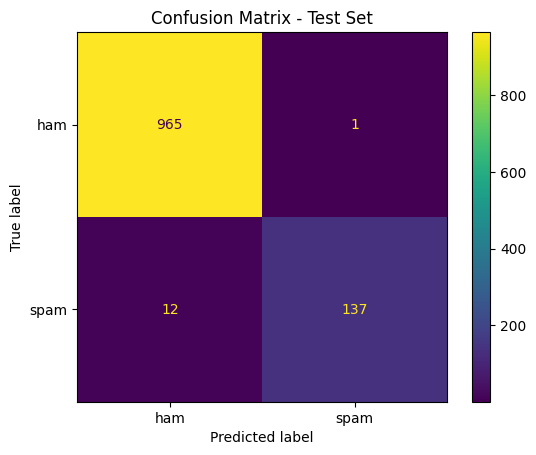

In [35]:
fig = ConfusionMatrixDisplay.from_predictions(
    all_labels, 
    all_preds, 
    display_labels=["ham", "spam"] 
)
# Ajouter un titre
fig.ax_.set_title("Confusion Matrix - Test Set")


In [36]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=["ham", "spam"],
    output_dict=True
)

df_score = pd.DataFrame(
    index=['Accuracy', 'Loss', "Precision(Spam)", "Recall(Spam)", "F1(Spam)"],
    columns=['Training', 'Validation', 'Test']
)

df_score.loc['Accuracy', 'Test'] = round(acc, 4)
df_score.loc['Accuracy', 'Validation'] = round(checkpoint['val_accuracy'], 4)
df_score.loc['Accuracy', 'Training'] = round(checkpoint['train_accuracy'], 4)

df_score.loc['Loss', 'Test'] = round(test_loss, 4)
df_score.loc['Loss', 'Validation'] = round(checkpoint['val_loss'], 4)
df_score.loc['Loss', 'Training'] = round(checkpoint['train_loss'], 4)

#Spam precision, recall and F1-score are computed only on the test set.
df_score.loc['Precision(Spam)', 'Test'] = round(report['spam']['precision'], 4)
df_score.loc['Recall(Spam)', 'Test'] = round(report['spam']['recall'], 4)
df_score.loc['F1(Spam)', 'Test'] = round(report['spam']['f1-score'], 4)

df_score

,Training,Validation,Test
Accuracy,0.9983,0.9832,0.9883
Loss,0.0115,0.0738,0.0623
Precision(Spam),NaN,NaN,0.9928
Recall(Spam),NaN,NaN,0.9195
F1(Spam),NaN,NaN,0.9547


The final model achieves 98.74% accuracy on the test set.  
For the spam class, it reaches a precision of 99.27%, a recall of 91.28%, and an F1-score of 95.10%.  
These results indicate strong spam detection performance with very low false positives and good generalization.

## Pre-trained Spam Model

We also use a pre-trained model (`mshenoda/roberta-spam`) to detect spam messages.  
The model is already trained and is used only for prediction on our dataset.  
This is not fine-tuning, since we do not retrain or update the model on our data.

In [37]:
from transformers import pipeline

# Load the pre-trained spam classification model
spam_classifier = pipeline("text-classification", model="mshenoda/roberta-spam")

# Convert your input data to a list of strings (if it's a pandas Series or similar)
texts_test = data.loc[x_test.index, 'messages'].tolist()  # or x_train.values.tolist() depending on your format
true_labels_test = data.loc[x_test.index, 'label']

# Run predictions in batches (recommended to avoid memory or speed issues)
predictions_test = spam_classifier(texts_test, batch_size=32)


Device set to use cpu


In [43]:
pred_df_test = pd.DataFrame(predictions_test)
pred_df_test.head()

,label,score
0,LABEL_0,0.999998
1,LABEL_0,0.999998
2,LABEL_0,0.999998
3,LABEL_1,0.999998
4,LABEL_0,0.999998


In [44]:
data['label']

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: label, Length: 5572, dtype: int64

In [45]:
pred_df_test['label'].str.split('_').str[1].astype(int)

0       0
1       0
2       0
3       1
4       0
       ..
1110    0
1111    0
1112    0
1113    0
1114    0
Name: label, Length: 1115, dtype: int64

In [46]:
true_labels_test = data.loc[x_test.index, 'label']
predicted_labels_test = pred_df_test['label'].str.split('_').str[1].astype(int)
print(classification_report(true_labels_test, predicted_labels_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       966
           1       0.99      0.99      0.99       149

    accuracy                           1.00      1115
   macro avg       1.00      0.99      0.99      1115
weighted avg       1.00      1.00      1.00      1115



Text(0.5, 1.0, 'Confusion Matrix - Spam Classifier')

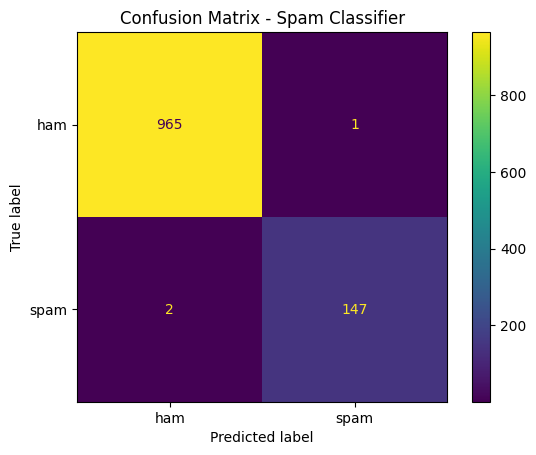

In [47]:
fig = ConfusionMatrixDisplay.from_predictions(
    true_labels_test, 
    predicted_labels_test, 
    display_labels=["ham", "spam"] 
)
# Ajouter un titre
fig.ax_.set_title("Confusion Matrix - Spam Classifier")

In [48]:
report_02 = classification_report(
    true_labels_test,
    predicted_labels_test,
    target_names=['ham', 'spam'],
    output_dict=True
)

df_score.loc['Precision(Spam) Roberta', 'Test'] = round(report_02['spam']['precision'], 4)
df_score.loc['Recall(Spam) Roberta', 'Test'] = round(report_02['spam']['recall'], 4)
df_score.loc['F1(Spam) Roberta', 'Test'] = round(report_02['spam']['f1-score'], 4)

df_score

,Training,Validation,Test
Accuracy,0.9983,0.9832,0.9883
Loss,0.0115,0.0738,0.0623
Precision(Spam),NaN,NaN,0.9928
Recall(Spam),NaN,NaN,0.9195
F1(Spam),NaN,NaN,0.9547
Precision(Spam) Roberta,NaN,NaN,0.9932
Recall(Spam) Roberta,NaN,NaN,0.9866
F1(Spam) Roberta,NaN,NaN,0.9899


While our custom deep learning model performs extremely well, the pre-trained RoBERTa model significantly improves spam recall (from 91.9% to 98.7%) while maintaining very high precision.

Given the limited dataset size and class imbalance, an obvious next step would be to leverage transfer learning by fine-tuning a pre-trained Transformer (DistilBERT / RoBERTa) on our SMS dataset.  